# Notebook 05 — R-Peak Detection Failure Diagnosis

Read-only investigation. No pipeline parameters are changed.

**Hypothesis:** The MAD-adaptive detector is firing on in-band oscillations
(not true R peaks) for animals 111 and 115. Evidence sought:
- RR intervals pinned near the 55 ms refractory floor
- HR from peak-count vs HR from mean-RR disagree substantially
- PSD of the filtered baseline signal has a dominant oscillation whose
  period matches the false inter-peak spacing
- Inverted polarity gives a more plausible HR

Reference animals 201 and 146 provide the 'working correctly' baseline.

In [1]:
# ── Configuration ─────────────────────────────────────────────────────────────
ANIMALS_DIAG  = [111, 115, 201, 146]   # problem cases first, then reference
PROBLEM_IDS   = {111, 115}
REFERENCE_IDS = {201, 146}

# Strip visualisation
STRIP_DUR_S    = 2.0   # seconds of signal to show in the strip plot
STRIP_OFFSET_S = 2.0   # skip this many seconds from window start (avoid filter edge)

# RR floor proximity threshold
REFRACTORY_MS  = 55    # pipeline constant (matches NB02)
FLOOR_BAND_MS  = 10    # 'near floor' = RR within this many ms of REFRACTORY_MS

# ── Imports ───────────────────────────────────────────────────────────────────
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.signal import butter, filtfilt, find_peaks, iirnotch, welch

# ── Project root ───────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR    = PROJECT_ROOT / 'data'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Animals      : {ANIMALS_DIAG}')

Project root : C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project
Animals      : [111, 115, 201, 146]


In [2]:
# ── Pipeline constants (NB02, verbatim) ───────────────────────────────────────
FS_DEFAULT       = 1000
BANDPASS_LOW_HZ  = 0.5
BANDPASS_HIGH_HZ = 150.0
BANDPASS_ORDER   = 2
HR_ACCEPT_LOW    = 300
HR_ACCEPT_HIGH   = 700
GAP_MIN_S        = 10
GAP_MAX_S        = 120
GAP_MAX_LONG_S   = 900
LONG_USE_S       = 60
SINGLE_FALLBACK_S = 30
EXCLUDE_KEYWORDS = ('oc 1', 'oc 2', 'oc1', 'oc2', 'jugular', 'jugcan', 'injection', 'inject')
END_KEYWORDS     = ('end', 'done', 'stop')
START_HINTS      = ('baseline', 'ecg', 'start')

_MARKER_RE = re.compile(r'#([*1-3])')

def _looks_like_end(text):
    low = text.lower()
    return any(k in low for k in END_KEYWORDS)

def _looks_like_excluded(text):
    low = text.lower()
    return any(k in low for k in EXCLUDE_KEYWORDS)

def _looks_like_baseline(text):
    return 'baseline' in text.lower().replace('basline', 'baseline')

def parse_header_and_layout(path):
    info = {}
    n_header = 0
    first_data_row = None
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            s = line.lstrip()
            if not s or s[0].isdigit() or s[0] in '+-.':
                first_data_row = line.rstrip('\n')
                break
            n_header += 1
            if '=' in line:
                key, _, rest = line.partition('=')
                info[key.strip()] = rest.strip('\n').strip('\t').split('\t')
    titles = [t.strip() for t in info.get('ChannelTitle', []) if t.strip()]
    n_channels = max(len(titles), 1)
    n_cols_first = len(first_data_row.split('\t')) if first_data_row else (n_channels + 1)
    lead_cols = max(1, n_cols_first - n_channels)
    ch3_idx = next((i for i, t in enumerate(titles) if t.lower() == 'channel 3'), 0)
    ecg_col = lead_cols + ch3_idx
    return n_header, lead_cols, ecg_col, titles

def load_ecg_file(path, n_header, ecg_col):
    voltages, markers = [], []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for _ in range(n_header):
            f.readline()
        for line in f:
            stripped = line.rstrip('\n')
            parts = stripped.split('\t')
            if len(parts) <= ecg_col:
                continue
            try:
                v = float(parts[ecg_col])
            except ValueError:
                v = np.nan
            voltages.append(v)
            m = _MARKER_RE.search(stripped)
            if m:
                markers.append((len(voltages) - 1, stripped[m.start():].strip(), m.group(1)))
    voltage = np.asarray(voltages, dtype=float)
    if np.isnan(voltage).any():
        idx = np.arange(len(voltage))
        good = ~np.isnan(voltage)
        if good.any():
            voltage = np.interp(idx, idx[good], voltage[good])
    return voltage, markers

def find_baseline_window(markers, n_samples, fs=FS_DEFAULT):
    MIN_GAP  = GAP_MIN_S      * fs
    MAX_GAP  = GAP_MAX_S      * fs
    LONG_GAP = GAP_MAX_LONG_S * fs
    LONG_USE = LONG_USE_S     * fs
    FALLBACK = SINGLE_FALLBACK_S * fs
    tagged = []
    for idx, text, prefix in markers:
        if _looks_like_excluded(text):
            continue
        tagged.append({'idx': idx, 'text': text, 'prefix': prefix, 'end': _looks_like_end(text)})
    starts = [m for m in tagged if not m['end']]
    ends   = [m for m in tagged if m['end']]
    def _try(_starts, _ends, lo, hi, label):
        for s in _starts:
            for e in _ends:
                if e['idx'] <= s['idx']:
                    continue
                gap = e['idx'] - s['idx']
                if lo <= gap <= hi:
                    return s, e, label
        return None
    for pre in ('*', '1', '2', '3'):
        result = _try([m for m in starts if m['prefix'] == pre],
                      [m for m in ends   if m['prefix'] == pre],
                      MIN_GAP, MAX_GAP, f'A_same_{pre}')
        if result:
            s, e, label = result
            return s['idx'], min(e['idx'], n_samples), label, s['text'], e['text']
    result = _try(starts, ends, MIN_GAP, MAX_GAP, 'B_cross')
    if result:
        s, e, label = result
        return s['idx'], min(e['idx'], n_samples), label, s['text'], e['text']
    bl_starts = [m for m in starts if _looks_like_baseline(m['text'])]
    bl_ends   = [m for m in ends   if _looks_like_baseline(m['text'])]
    result = _try(bl_starts, bl_ends, MIN_GAP, LONG_GAP, 'C_long_baseline')
    if result:
        s, e, label = result
        return s['idx'], min(s['idx'] + LONG_USE, e['idx'], n_samples), label, s['text'], e['text']
    candidate = next((m for m in starts if any(k in m['text'].lower() for k in START_HINTS)), None)
    if candidate is None and starts:
        candidate = starts[0]
    if candidate is None and tagged:
        candidate = tagged[0]
    if candidate is not None:
        return candidate['idx'], min(candidate['idx'] + FALLBACK, n_samples), 'D_single_30s', candidate['text'], None
    return None, None, 'no_markers', None, None

def bandpass_filter(x, fs=FS_DEFAULT, low=BANDPASS_LOW_HZ, high=BANDPASS_HIGH_HZ, order=BANDPASS_ORDER):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    y = filtfilt(b, a, x)
    for f0 in (50, 100, 150):
        bn, an = iirnotch(f0 / (fs / 2), Q=30)
        y = filtfilt(bn, an, y)
    return y

def _peaks_with_mad(sig, fs=FS_DEFAULT, refractory_ms=REFRACTORY_MS):
    if sig.size == 0:
        return np.array([], dtype=int), np.nan, np.nan
    med = float(np.median(sig))
    mad = float(np.median(np.abs(sig - med)))
    if mad <= 0:
        return np.array([], dtype=int), med, mad
    height     = med + 4 * mad
    prominence = max(0.3 * mad, 0.005)
    distance   = int(refractory_ms * fs / 1000)
    peaks, _   = find_peaks(sig, height=height, distance=distance, prominence=prominence)
    return peaks, height, prominence

def detect_r_peaks(sig, fs=FS_DEFAULT):
    def _hr(peaks):
        if len(peaks) < 2:
            return np.nan
        return 60000.0 / np.mean(np.diff(peaks) * (1000.0 / fs))
    pos_peaks, pos_h, _ = _peaks_with_mad(sig, fs)
    pos_hr = _hr(pos_peaks)
    if HR_ACCEPT_LOW <= pos_hr <= HR_ACCEPT_HIGH if not np.isnan(pos_hr) else False:
        return pos_peaks, False, pos_hr, pos_h
    inv_peaks, inv_h, _ = _peaks_with_mad(-sig, fs)
    inv_hr = _hr(inv_peaks)
    if HR_ACCEPT_LOW <= inv_hr <= HR_ACCEPT_HIGH if not np.isnan(inv_hr) else False:
        return inv_peaks, True, inv_hr, inv_h
    def _dist(hr):
        if np.isnan(hr): return np.inf
        if hr < HR_ACCEPT_LOW: return HR_ACCEPT_LOW - hr
        if hr > HR_ACCEPT_HIGH: return hr - HR_ACCEPT_HIGH
        return 0.0
    if _dist(inv_hr) < _dist(pos_hr):
        return inv_peaks, True, inv_hr, inv_h
    return pos_peaks, False, pos_hr, pos_h

def read_fs_from_header(path):
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            s = line.lstrip()
            if s and (s[0].isdigit() or s[0] in '+-'):
                break
            if line.lower().startswith('interval'):
                m = re.search(r'([\d.]+(?:[eE][+-]?\d+)?)\s*s', line, re.IGNORECASE)
                if m:
                    iv = float(m.group(1))
                    if iv > 0:
                        return int(round(1.0 / iv))
    return None

def find_animal_file(animal_id, data_dir):
    for path in sorted(data_dir.glob('*.txt')):
        nums = re.findall(r'\d+', path.stem)
        if nums and int(nums[-1]) == animal_id:
            return path
    return None

print('Helper functions loaded.')

Helper functions loaded.


In [3]:
diag_rows  = []
strip_data = {}   # saved for the combined strip plot
psd_data   = {}   # saved for the combined PSD plot

for animal_id in ANIMALS_DIAG:
    tag = 'PROBLEM' if animal_id in PROBLEM_IDS else 'REF'
    print(f'\n{"="*72}')
    print(f'  ANIMAL {animal_id}  [{tag}]')
    print(f'{"="*72}')

    path = find_animal_file(animal_id, DATA_DIR)
    if path is None:
        print(f'  ERROR: file not found')
        continue
    print(f'  File : {path.name}')

    fs = read_fs_from_header(path) or FS_DEFAULT
    print(f'  fs   : {fs} Hz')

    n_header, _, ecg_col, titles = parse_header_and_layout(path)
    voltage, markers = load_ecg_file(path, n_header, ecg_col)
    start, end, rule, s_text, _ = find_baseline_window(markers, len(voltage), fs)
    if start is None:
        print(f'  ERROR: no baseline window')
        continue

    seg_raw  = voltage[start:end].copy()
    seg_filt = bandpass_filter(seg_raw, fs=fs)
    dur_s    = len(seg_raw) / fs
    print(f'  Baseline : {start/fs:.1f}s -> {end/fs:.1f}s  ({dur_s:.1f}s)  [{rule}]')

    # ── Polarity check: run both polarities explicitly ────────────────────────
    pos_peaks, pos_h, _ = _peaks_with_mad(seg_filt, fs)
    inv_peaks, inv_h, _ = _peaks_with_mad(-seg_filt, fs)

    def _hr_from_peaks(peaks, fs):
        if len(peaks) < 2: return np.nan
        return float(60000.0 / np.mean(np.diff(peaks) * 1000.0 / fs))

    pos_hr_mean = _hr_from_peaks(pos_peaks, fs)
    inv_hr_mean = _hr_from_peaks(inv_peaks, fs)
    pos_in_gate = HR_ACCEPT_LOW <= pos_hr_mean <= HR_ACCEPT_HIGH if not np.isnan(pos_hr_mean) else False
    inv_in_gate = HR_ACCEPT_LOW <= inv_hr_mean <= HR_ACCEPT_HIGH if not np.isnan(inv_hr_mean) else False

    # detect_r_peaks() result (what the pipeline actually uses)
    peaks, inverted, pipeline_hr, _ = detect_r_peaks(seg_filt, fs=fs)
    polarity_chosen = 'INVERTED' if inverted else 'POSITIVE'

    print(f'  Polarity check:')
    print(f'    POS  : n={len(pos_peaks)}  HR_mean={pos_hr_mean:.1f} bpm  in_gate={pos_in_gate}')
    print(f'    INV  : n={len(inv_peaks)}  HR_mean={inv_hr_mean:.1f} bpm  in_gate={inv_in_gate}')
    print(f'    Chosen by detect_r_peaks: {polarity_chosen}  (pipeline HR={pipeline_hr:.1f} bpm)')

    # ── RR distribution on the chosen peaks ───────────────────────────────────
    # Use peaks as-is (inverted flag already embedded in detect_r_peaks output)
    if inverted:
        seg_raw  = -seg_raw
        seg_filt = -seg_filt

    n_peaks = len(peaks)
    if n_peaks < 2:
        print(f'  ERROR: fewer than 2 peaks')
        continue

    rr_ms = np.diff(peaks) * 1000.0 / fs

    rr_min  = float(np.min(rr_ms))
    rr_p5   = float(np.percentile(rr_ms, 5))
    rr_p50  = float(np.percentile(rr_ms, 50))
    rr_p95  = float(np.percentile(rr_ms, 95))
    rr_mean = float(np.mean(rr_ms))

    # Fraction of RR intervals within FLOOR_BAND_MS of the refractory floor
    pct_floor = float(np.mean(rr_ms <= (REFRACTORY_MS + FLOOR_BAND_MS)) * 100)

    # HR three ways
    hr_count  = n_peaks / dur_s * 60       # simple count rate
    hr_mean   = 60000.0 / rr_mean          # what pipeline uses (same as pipeline_hr)
    hr_median = 60000.0 / rr_p50           # median-based
    hr_divergence = abs(hr_count - hr_median)  # should be ~0 if detection is clean

    print(f'  RR distribution ({len(rr_ms)} intervals):')
    print(f'    min={rr_min:.1f}  p5={rr_p5:.1f}  median={rr_p50:.1f}  p95={rr_p95:.1f}  mean={rr_mean:.1f} ms')
    print(f'    % within {FLOOR_BAND_MS} ms of {REFRACTORY_MS} ms floor : {pct_floor:.1f}%')
    print(f'    Min RR hits floor exactly: {rr_min <= REFRACTORY_MS + 0.5}')
    print(f'  HR three ways:')
    print(f'    count-based  : {hr_count:.1f} bpm  (n_peaks / duration)')
    print(f'    mean-RR      : {hr_mean:.1f} bpm  (pipeline value — 60000/mean_RR)')
    print(f'    median-RR    : {hr_median:.1f} bpm')
    flag_div = '  *** HIGH DIVERGENCE ***' if hr_divergence > 50 else ''
    print(f'    count vs median divergence: {hr_divergence:.1f} bpm{flag_div}')

    # ── PSD of filtered baseline segment ──────────────────────────────────────
    nperseg = min(4 * fs, len(seg_filt) // 4)
    f_ax, psd = welch(seg_filt, fs=fs, nperseg=nperseg)
    # Focus above 0.5 Hz (bandpass floor) to exclude DC drift
    mask_bp   = (f_ax >= 0.5) & (f_ax <= 150.0)
    # Exclude notch bands ±2 Hz around 50/100/150 Hz
    notch_mask = np.ones(len(f_ax), dtype=bool)
    for fn in (50, 100, 150):
        notch_mask &= np.abs(f_ax - fn) > 2
    search_mask = mask_bp & notch_mask
    # Also report the peak including near-notch (tells us if 50 Hz leaked through)
    peak_f_all  = float(f_ax[mask_bp][np.argmax(psd[mask_bp])])
    peak_f_safe = float(f_ax[search_mask][np.argmax(psd[search_mask])])
    psd_at_notch  = float(np.max(psd[(f_ax >= 48) & (f_ax <= 52)]))
    psd_at_hr_band = float(np.max(psd[(f_ax >= 4) & (f_ax <= 12)]))
    period_all_ms  = 1000.0 / peak_f_all  if peak_f_all  > 0 else np.nan
    period_safe_ms = 1000.0 / peak_f_safe if peak_f_safe > 0 else np.nan

    print(f'  PSD (Welch, nperseg={nperseg}):')
    print(f'    Dominant freq (all passband)  : {peak_f_all:.2f} Hz  period={period_all_ms:.1f} ms')
    print(f'    Dominant freq (excl ±2Hz notch): {peak_f_safe:.2f} Hz  period={period_safe_ms:.1f} ms')
    print(f'    Power near 50 Hz (48-52 Hz)   : {psd_at_notch:.4f}')
    print(f'    Power in HR band (4-12 Hz)    : {psd_at_hr_band:.4f}')
    ratio = psd_at_notch / psd_at_hr_band if psd_at_hr_band > 0 else np.nan
    flag_50  = '  *** MAINS LEAKAGE ***' if ratio > 5 else ''
    print(f'    50Hz / HR-band power ratio    : {ratio:.1f}{flag_50}')
    rr_match = abs(period_all_ms - rr_p5) < 15 if not np.isnan(period_all_ms) else False
    print(f'    Period matches p5 RR ({rr_p5:.0f}ms)?  {rr_match}')

    # ── Save for combined plots ────────────────────────────────────────────────
    strip_s = int(STRIP_OFFSET_S * fs)
    strip_e = min(strip_s + int(STRIP_DUR_S * fs), len(seg_filt))
    strip_peaks = peaks[(peaks >= strip_s) & (peaks < strip_e)] - strip_s
    t_strip = np.arange(strip_e - strip_s) / fs * 1000  # ms

    strip_data[animal_id] = {
        'raw':    seg_raw [strip_s:strip_e],
        'filt':   seg_filt[strip_s:strip_e],
        't_ms':   t_strip,
        'peaks':  strip_peaks,
        'n_total': n_peaks,
        'inverted': inverted,
    }
    psd_data[animal_id] = {'f': f_ax, 'psd': psd, 'peak_f': peak_f_all,
                           'notch_power': psd_at_notch, 'hr_power': psd_at_hr_band}
    rr_data_key = f'rr_{animal_id}'
    strip_data[rr_data_key] = rr_ms

    diag_rows.append({
        'animal':        animal_id,
        'group':         tag,
        'fs_hz':         fs,
        'dur_s':         round(dur_s, 1),
        'n_peaks':       n_peaks,
        'polarity':      polarity_chosen,
        'pos_hr':        round(pos_hr_mean, 1),
        'inv_hr':        round(inv_hr_mean, 1),
        'pipeline_hr':   round(pipeline_hr, 1),
        'rr_min_ms':     round(rr_min, 1),
        'rr_p5_ms':      round(rr_p5, 1),
        'rr_median_ms':  round(rr_p50, 1),
        'rr_p95_ms':     round(rr_p95, 1),
        'hr_count':      round(hr_count, 1),
        'hr_mean_rr':    round(hr_mean, 1),
        'hr_median_rr':  round(hr_median, 1),
        'pct_near_floor': round(pct_floor, 1),
        'psd_dom_hz':    round(peak_f_all, 2),
        'psd_dom_period_ms': round(period_all_ms, 1),
        '50hz_vs_hr_ratio': round(ratio, 1) if not np.isnan(ratio) else None,
    })

print(f'\n{"="*72}')
print('  LOOP COMPLETE')
print(f'{"="*72}')


  ANIMAL 111  [PROBLEM]
  File : 2024_11_13_111.txt
  fs   : 1000 Hz


  Baseline : 266.3s -> 281.4s  (15.1s)  [A_same_*]
  Polarity check:
    POS  : n=72  HR_mean=283.6 bpm  in_gate=False
    INV  : n=68  HR_mean=269.0 bpm  in_gate=False
    Chosen by detect_r_peaks: POSITIVE  (pipeline HR=283.6 bpm)
  RR distribution (71 intervals):
    min=55.0  p5=60.0  median=80.0  p95=993.0  mean=211.6 ms
    % within 10 ms of 55 ms floor : 16.9%
    Min RR hits floor exactly: True
  HR three ways:
    count-based  : 286.1 bpm  (n_peaks / duration)
    mean-RR      : 283.6 bpm  (pipeline value — 60000/mean_RR)
    median-RR    : 750.0 bpm
    count vs median divergence: 463.9 bpm  *** HIGH DIVERGENCE ***
  PSD (Welch, nperseg=3775):
    Dominant freq (all passband)  : 74.97 Hz  period=13.3 ms
    Dominant freq (excl ±2Hz notch): 74.97 Hz  period=13.3 ms
    Power near 50 Hz (48-52 Hz)   : 0.0121
    Power in HR band (4-12 Hz)    : 0.0002
    50Hz / HR-band power ratio    : 72.0  *** MAINS LEAKAGE ***
    Period matches p5 RR (60ms)?  False

  ANIMAL 115  [PROBLEM]


  Baseline : 66.8s -> 121.0s  (54.2s)  [A_same_*]
  Polarity check:
    POS  : n=408  HR_mean=454.9 bpm  in_gate=True
    INV  : n=232  HR_mean=257.7 bpm  in_gate=False
    Chosen by detect_r_peaks: POSITIVE  (pipeline HR=454.9 bpm)
  RR distribution (407 intervals):
    min=60.0  p5=80.0  median=80.0  p95=120.0  mean=131.9 ms
    % within 10 ms of 55 ms floor : 1.2%
    Min RR hits floor exactly: False
  HR three ways:
    count-based  : 451.6 bpm  (n_peaks / duration)
    mean-RR      : 454.9 bpm  (pipeline value — 60000/mean_RR)
    median-RR    : 750.0 bpm
    count vs median divergence: 298.4 bpm  *** HIGH DIVERGENCE ***
  PSD (Welch, nperseg=4000):
    Dominant freq (all passband)  : 10.75 Hz  period=93.0 ms
    Dominant freq (excl ±2Hz notch): 10.75 Hz  period=93.0 ms
    Power near 50 Hz (48-52 Hz)   : 0.0317
    Power in HR band (4-12 Hz)    : 0.1774
    50Hz / HR-band power ratio    : 0.2
    Period matches p5 RR (80ms)?  True

  ANIMAL 201  [REF]
  File : 2024_12_14_201.txt


  Baseline : 94.6s -> 119.6s  (25.0s)  [A_same_*]
  Polarity check:
    POS  : n=208  HR_mean=499.3 bpm  in_gate=True
    INV  : n=35  HR_mean=87.9 bpm  in_gate=False
    Chosen by detect_r_peaks: POSITIVE  (pipeline HR=499.3 bpm)
  RR distribution (207 intervals):
    min=55.0  p5=120.0  median=121.0  p95=123.0  mean=120.2 ms
    % within 10 ms of 55 ms floor : 1.4%
    Min RR hits floor exactly: True
  HR three ways:
    count-based  : 499.2 bpm  (n_peaks / duration)
    mean-RR      : 499.3 bpm  (pipeline value — 60000/mean_RR)
    median-RR    : 495.9 bpm
    count vs median divergence: 3.3 bpm
  PSD (Welch, nperseg=4000):
    Dominant freq (all passband)  : 16.50 Hz  period=60.6 ms
    Dominant freq (excl ±2Hz notch): 16.50 Hz  period=60.6 ms
    Power near 50 Hz (48-52 Hz)   : 0.0000
    Power in HR band (4-12 Hz)    : 0.0035
    50Hz / HR-band power ratio    : 0.0
    Period matches p5 RR (120ms)?  False

  ANIMAL 146  [REF]
  File : 2024_11_19_146.txt
  fs   : 1000 Hz


  Baseline : 69.5s -> 91.0s  (21.4s)  [A_same_*]
  Polarity check:
    POS  : n=145  HR_mean=405.7 bpm  in_gate=True
    INV  : n=8  HR_mean=22.8 bpm  in_gate=False
    Chosen by detect_r_peaks: POSITIVE  (pipeline HR=405.7 bpm)
  RR distribution (144 intervals):
    min=64.0  p5=143.0  median=151.0  p95=155.0  mean=147.9 ms
    % within 10 ms of 55 ms floor : 0.7%
    Min RR hits floor exactly: False
  HR three ways:
    count-based  : 405.6 bpm  (n_peaks / duration)
    mean-RR      : 405.7 bpm  (pipeline value — 60000/mean_RR)
    median-RR    : 397.4 bpm
    count vs median divergence: 8.2 bpm
  PSD (Welch, nperseg=4000):
    Dominant freq (all passband)  : 13.25 Hz  period=75.5 ms
    Dominant freq (excl ±2Hz notch): 13.25 Hz  period=75.5 ms
    Power near 50 Hz (48-52 Hz)   : 0.0000
    Power in HR band (4-12 Hz)    : 0.0018
    50Hz / HR-band power ratio    : 0.0
    Period matches p5 RR (143ms)?  False

  LOOP COMPLETE


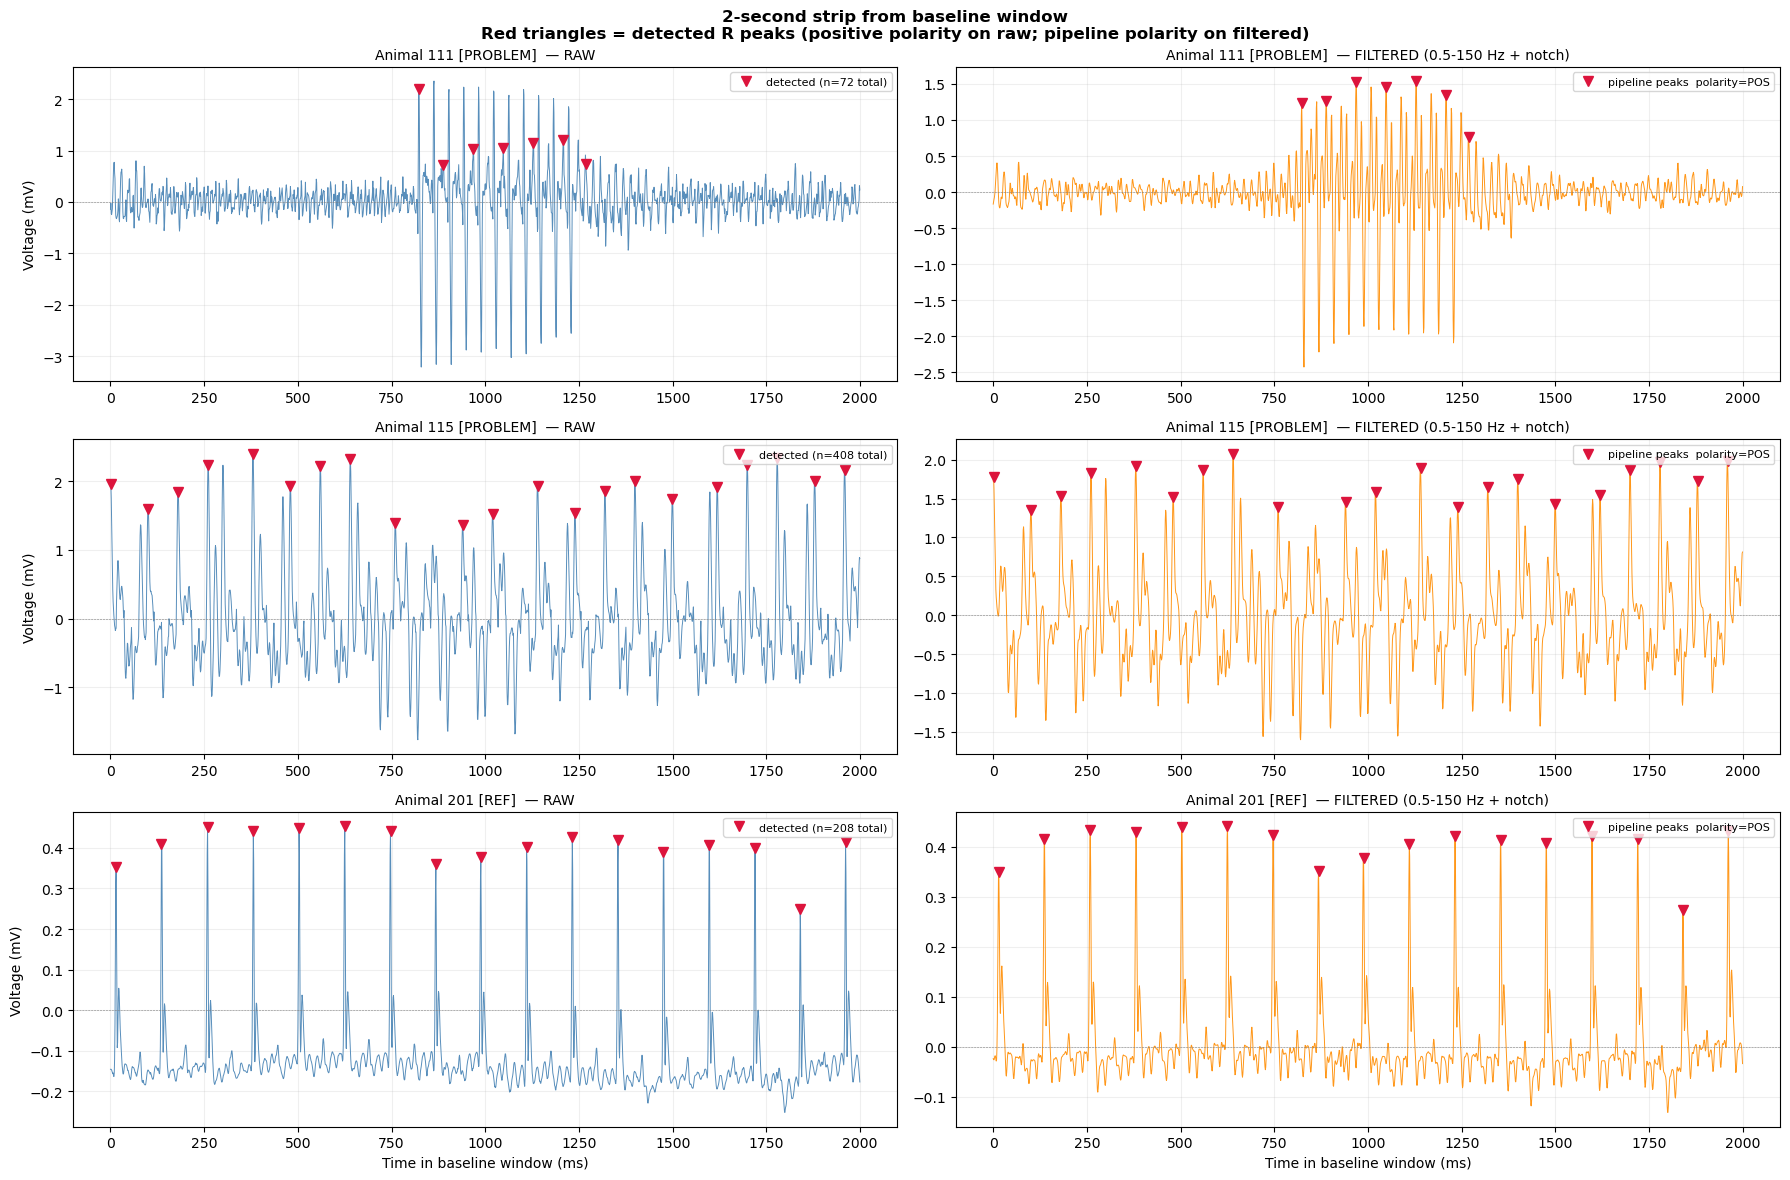

Saved: 05_strip_diagnosis.png


In [4]:
# ── Combined strip plot: 2 seconds of raw + filtered, peaks marked ─────────────
# Rows = animals (111, 115, 201 as reference), Cols = raw | filtered
show_ids = [111, 115, 201]   # 201 is the 'this is correct' reference
n_show   = len(show_ids)

fig, axes = plt.subplots(n_show, 2, figsize=(18, 4 * n_show), sharex='row')
fig.suptitle(
    f'{STRIP_DUR_S:.0f}-second strip from baseline window\n'
    f'Red triangles = detected R peaks (positive polarity on raw; pipeline polarity on filtered)',
    fontsize=12, fontweight='bold')

for row, aid in enumerate(show_ids):
    if aid not in strip_data:
        continue
    sd    = strip_data[aid]
    t_ms  = sd['t_ms']
    raw   = sd['raw']
    filt  = sd['filt']
    peaks = sd['peaks']   # indices into strip
    inv   = sd['inverted']
    tag   = 'PROBLEM' if aid in PROBLEM_IDS else 'REF'

    # Left: raw signal — show positive-polarity peaks for visual reference
    ax_r = axes[row, 0]
    ax_r.plot(t_ms, raw, color='steelblue', linewidth=0.7, alpha=0.9)
    if len(peaks):
        ax_r.plot(t_ms[peaks], raw[peaks], 'v', color='crimson', ms=7,
                  zorder=5, label=f'detected (n={sd["n_total"]} total)')
    ax_r.axhline(0, color='gray', linewidth=0.4, linestyle='--')
    ax_r.set_title(f'Animal {aid} [{tag}]  — RAW', fontsize=10)
    ax_r.set_ylabel('Voltage (mV)')
    ax_r.legend(fontsize=8, loc='upper right')
    ax_r.grid(alpha=0.2)

    # Right: filtered signal with pipeline peaks
    ax_f = axes[row, 1]
    ax_f.plot(t_ms, filt, color='darkorange', linewidth=0.7, alpha=0.9)
    if len(peaks):
        ax_f.plot(t_ms[peaks], filt[peaks], 'v', color='crimson', ms=7,
                  zorder=5, label=f'pipeline peaks  polarity={"INV" if inv else "POS"}')
    ax_f.axhline(0, color='gray', linewidth=0.4, linestyle='--')
    ax_f.set_title(f'Animal {aid} [{tag}]  — FILTERED (0.5-150 Hz + notch)', fontsize=10)
    ax_f.legend(fontsize=8, loc='upper right')
    ax_f.grid(alpha=0.2)

    if row == n_show - 1:
        ax_r.set_xlabel('Time in baseline window (ms)')
        ax_f.set_xlabel('Time in baseline window (ms)')

fig.tight_layout()
fig_path = FIGURES_DIR / '05_strip_diagnosis.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path.name}')

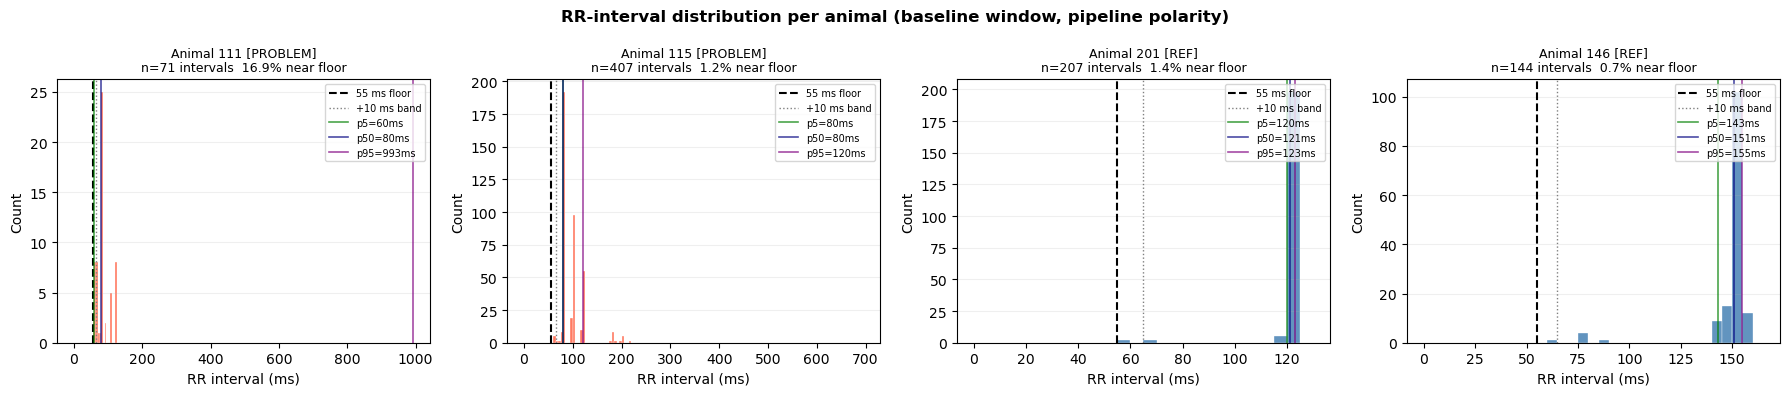

Saved: 05_rr_histograms.png


In [5]:
# ── RR histogram grid: all 4 animals side by side ────────────────────────────
fig, axes = plt.subplots(1, len(ANIMALS_DIAG), figsize=(18, 4), sharey=False)
fig.suptitle('RR-interval distribution per animal (baseline window, pipeline polarity)',
             fontsize=12, fontweight='bold')

for ax, aid in zip(axes, ANIMALS_DIAG):
    key = f'rr_{aid}'
    if key not in strip_data:
        ax.set_title(f'Animal {aid} — no data')
        continue
    rr = strip_data[key]
    tag = 'PROBLEM' if aid in PROBLEM_IDS else 'REF'

    # Histogram with bins at 5 ms resolution
    bins = np.arange(0, min(700, rr.max() + 10), 5)
    ax.hist(rr, bins=bins, color='steelblue' if tag == 'REF' else 'tomato',
            edgecolor='white', linewidth=0.3, alpha=0.85)

    # Mark the refractory floor and floor+band
    ax.axvline(REFRACTORY_MS,              color='black',  linewidth=1.5,
               linestyle='--', label=f'{REFRACTORY_MS} ms floor')
    ax.axvline(REFRACTORY_MS + FLOOR_BAND_MS, color='gray', linewidth=1.0,
               linestyle=':', label=f'+{FLOOR_BAND_MS} ms band')

    # Percentile lines
    for pct, val, col in [(5, np.percentile(rr, 5), 'green'),
                          (50, np.percentile(rr, 50), 'navy'),
                          (95, np.percentile(rr, 95), 'purple')]:
        ax.axvline(val, color=col, linewidth=1.2, linestyle='-', alpha=0.7,
                   label=f'p{pct}={val:.0f}ms')

    pct_floor = np.mean(rr <= (REFRACTORY_MS + FLOOR_BAND_MS)) * 100
    ax.set_title(f'Animal {aid} [{tag}]\n'
                 f'n={len(rr)} intervals  {pct_floor:.1f}% near floor', fontsize=9)
    ax.set_xlabel('RR interval (ms)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.2, axis='y')

fig.tight_layout()
fig_path = FIGURES_DIR / '05_rr_histograms.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path.name}')

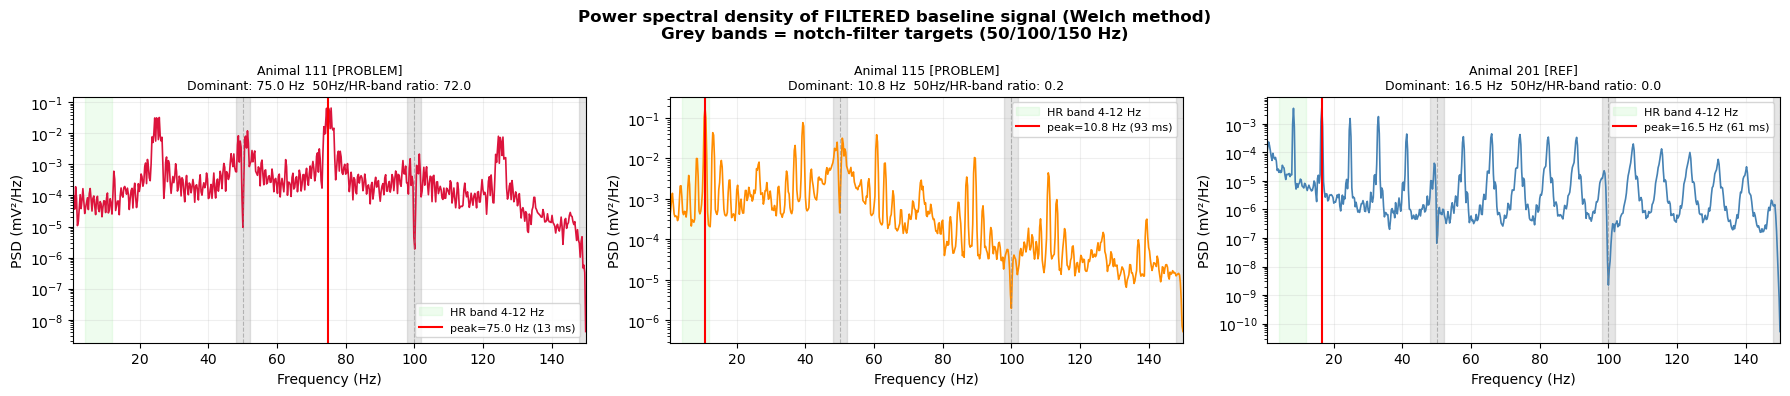

Saved: 05_psd_comparison.png


In [6]:
# ── PSD comparison: 111 / 115 / 201 ─────────────────────────────────────────
psd_ids = [111, 115, 201]
colors  = {'111': 'crimson', '115': 'darkorange', '201': 'steelblue'}
fig, axes = plt.subplots(1, len(psd_ids), figsize=(18, 4))
fig.suptitle('Power spectral density of FILTERED baseline signal (Welch method)\n'
             'Grey bands = notch-filter targets (50/100/150 Hz)',
             fontsize=12, fontweight='bold')

for ax, aid in zip(axes, psd_ids):
    if aid not in psd_data:
        ax.set_title(f'Animal {aid} — no data')
        continue
    pd_d  = psd_data[aid]
    f_ax  = pd_d['f']
    psd   = pd_d['psd']
    tag   = 'PROBLEM' if aid in PROBLEM_IDS else 'REF'
    col   = 'crimson' if aid == 111 else ('darkorange' if aid == 115 else 'steelblue')

    mask = (f_ax >= 0.5) & (f_ax <= 150)
    ax.semilogy(f_ax[mask], psd[mask], color=col, linewidth=1.2)

    # Shade notch bands
    for fn in (50, 100, 150):
        ax.axvspan(fn - 2, fn + 2, color='gray', alpha=0.2)
        ax.axvline(fn, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

    # Mark HR band and dominant peak
    ax.axvspan(4, 12, color='lightgreen', alpha=0.15, label='HR band 4-12 Hz')
    pf = pd_d['peak_f']
    ax.axvline(pf, color='red', linewidth=1.5, linestyle='-',
               label=f'peak={pf:.1f} Hz ({1000/pf:.0f} ms)')

    ratio = pd_d['notch_power'] / pd_d['hr_power'] if pd_d['hr_power'] > 0 else np.nan
    ax.set_title(f'Animal {aid} [{tag}]\n'
                 f'Dominant: {pf:.1f} Hz  50Hz/HR-band ratio: {ratio:.1f}', fontsize=9)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (mV²/Hz)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    ax.set_xlim(0.5, 150)

fig.tight_layout()
fig_path = FIGURES_DIR / '05_psd_comparison.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path.name}')

In [7]:
# ── Summary table ─────────────────────────────────────────────────────────────
if diag_rows:
    ddf = pd.DataFrame(diag_rows)
    print('\n' + '='*72)
    print('DIAGNOSTIC SUMMARY TABLE')
    print('='*72)
    cols_print = ['animal', 'group', 'n_peaks', 'polarity',
                  'pos_hr', 'inv_hr', 'pipeline_hr',
                  'rr_min_ms', 'rr_p5_ms', 'rr_median_ms', 'rr_p95_ms',
                  'hr_count', 'hr_mean_rr', 'hr_median_rr',
                  'pct_near_floor', 'psd_dom_hz', 'psd_dom_period_ms', '50hz_vs_hr_ratio']
    with pd.option_context('display.max_columns', 30, 'display.width', 160,
                           'display.float_format', '{:.1f}'.format):
        print(ddf[cols_print].to_string(index=False))
    ddf.to_csv(OUTPUTS_DIR / 'detect_diagnosis.csv', index=False)
    print(f'\nSaved: outputs/detect_diagnosis.csv')

    print('\n' + '='*72)
    print('INTERPRETATION NOTES')
    print('='*72)
    print('rr_min_ms       : minimum inter-peak interval detected')
    print('                  AT 55 ms -> hitting the refractory floor')
    print('pct_near_floor  : % RR intervals <= 65 ms (floor + 10 ms window)')
    print('                  HIGH -> detector fires as fast as refractory allows')
    print('hr_count        : n_peaks / duration * 60  (actual count rate)')
    print('hr_median_rr    : 60000 / median_RR  (most robust to outliers)')
    print('divergence      : hr_count vs hr_median should agree if detection is clean')
    print('psd_dom_hz      : dominant frequency in the FILTERED baseline signal')
    print('                  should be near the true HR (4-12 Hz for 240-720 bpm)')
    print('                  near 50 Hz -> mains interference survived the notch')
    print('50hz_vs_hr_ratio: >5 = mains power dominates over cardiac signal')
else:
    print('No data collected.')


DIAGNOSTIC SUMMARY TABLE
 animal   group  n_peaks polarity  pos_hr  inv_hr  pipeline_hr  rr_min_ms  rr_p5_ms  rr_median_ms  rr_p95_ms  hr_count  hr_mean_rr  hr_median_rr  pct_near_floor  psd_dom_hz  psd_dom_period_ms  50hz_vs_hr_ratio
    111 PROBLEM       72 POSITIVE   283.6   269.0        283.6       55.0      60.0          80.0      993.0     286.1       283.6         750.0            16.9        75.0               13.3              72.0
    115 PROBLEM      408 POSITIVE   454.9   257.7        454.9       60.0      80.0          80.0      120.0     451.6       454.9         750.0             1.2        10.8               93.0               0.2
    201     REF      208 POSITIVE   499.3    87.9        499.3       55.0     120.0         121.0      123.0     499.2       499.3         495.9             1.4        16.5               60.6               0.0
    146     REF      145 POSITIVE   405.7    22.8        405.7       64.0     143.0         151.0      155.0     405.6       405.7    